# 04 - Explicabilité : SHAP

**Étape CRISP-DM : Evaluation (interprétation du modèle)**

Cœur du projet FraudShield : un modèle de détection de fraude bancaire ne peut pas être une
boîte noire. Un analyste doit pouvoir justifier pourquoi une transaction est bloquée (exigence
métier et réglementaire). SHAP (TreeExplainer, exact pour les modèles à arbres) fournit :
1. Une **importance globale** cohérente avec la théorie des jeux (valeurs de Shapley)
2. Une **explication par transaction** : contribution de chaque variable à la prédiction

Le calcul SHAP se fait sur un **échantillon** (pas les 590k lignes) : c'est la pratique standard,
suffisant pour une importance globale stable, et nécessaire pour rester rapide/léger en mémoire.

In [1]:
import os
import sys

import numpy as np
import pandas as pd

sys.path.append(os.path.join(".."))

from src.pipeline import get_column_types, TARGET_COL
from src.models import get_feature_columns, load_model, time_based_split
from src.explainer import (
    get_explainer,
    compute_shap_values,
    plot_global_importance,
    plot_transaction_explanation,
    top_contributing_features,
)

DATA_PATH = os.path.join("..", "data", "processed", "train_clean.parquet")
MODEL_PATH = os.path.join("..", "models", "lightgbm_baseline.pkl")
SAMPLE_SIZE = 3000
RANDOM_STATE = 42

In [2]:
model = load_model(MODEL_PATH)

df = pd.read_parquet(DATA_PATH)
feature_cols = get_feature_columns(df)

_, test = time_based_split(df, test_size=0.2)
test = test.copy()
del df

# Echantillon stratifie : on force une part de fraudes pour avoir des exemples
# a expliquer individuellement, plutot qu'un tirage aleatoire pur (3.5% de fraude
# donnerait trop peu de cas positifs dans un petit echantillon).
fraud_sample = test[test[TARGET_COL] == 1].sample(n=min(500, (test[TARGET_COL] == 1).sum()), random_state=RANDOM_STATE)
non_fraud_sample = test[test[TARGET_COL] == 0].sample(n=SAMPLE_SIZE - len(fraud_sample), random_state=RANDOM_STATE)
sample = pd.concat([fraud_sample, non_fraud_sample]).sample(frac=1, random_state=RANDOM_STATE)

X_sample = sample[feature_cols].astype(np.float32)
print(f"Echantillon SHAP : {X_sample.shape}, dont {sample[TARGET_COL].sum()} fraudes")

Echantillon SHAP : (3000, 432), dont 500 fraudes


In [3]:
explainer = get_explainer(model)
explanation = compute_shap_values(explainer, X_sample)
print("SHAP values calculees :", explanation.values.shape)

SHAP values calculees : (3000, 432)


## Importance globale

Chaque point est une transaction de l'échantillon. La position horizontale indique l'impact sur
la prédiction (pousse vers "fraude" ou "non-fraude"), la couleur la valeur de la variable.

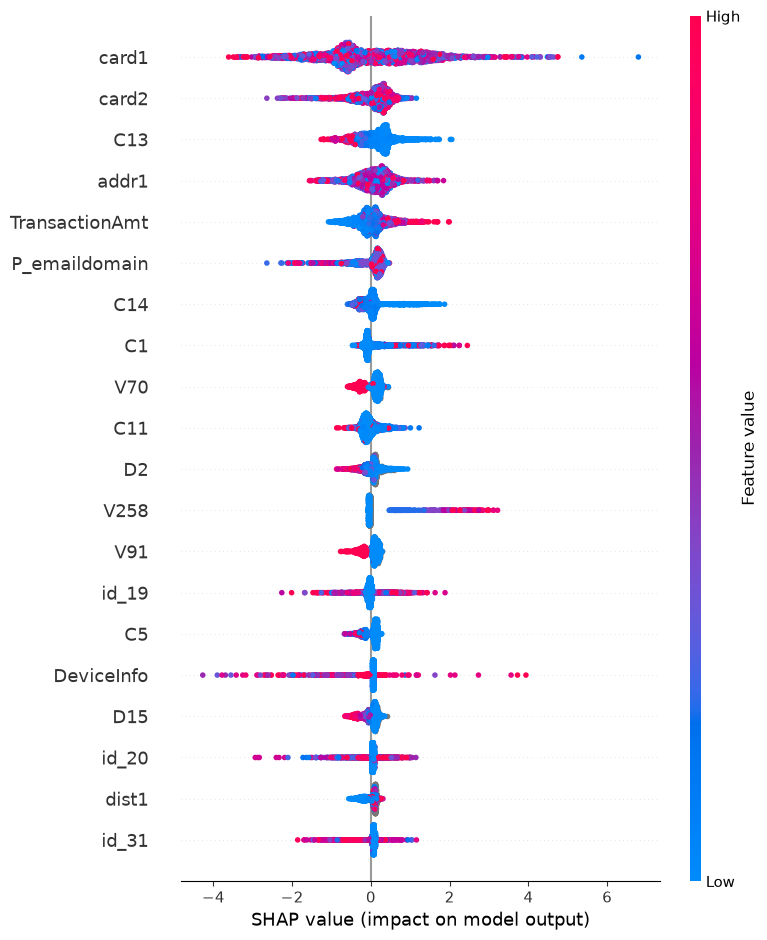

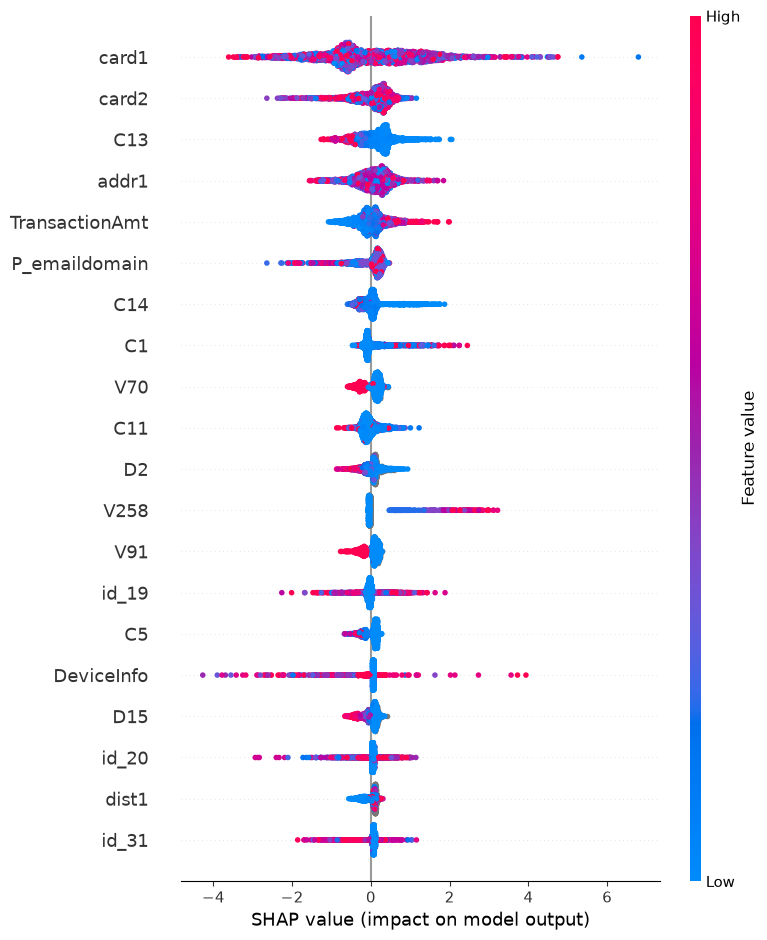

In [4]:
plot_global_importance(explanation, max_display=20)

## Explication d'une transaction individuelle

On compare deux cas : une fraude correctement détectée avec forte confiance, et une fraude
manquée par le modèle (faux négatif) — ce deuxième cas est le plus instructif pour un analyste.

In [5]:
y_proba_sample = model.predict_proba(X_sample)[:, 1]
sample = sample.reset_index(drop=True)
sample["proba_fraude"] = y_proba_sample

fraud_mask = sample[TARGET_COL] == 1
idx_detected = sample[fraud_mask].sort_values("proba_fraude", ascending=False).index[0]
idx_missed_candidates = sample[fraud_mask].sort_values("proba_fraude").index
idx_missed = idx_missed_candidates[0] if sample.loc[idx_missed_candidates[0], "proba_fraude"] < 0.5 else None

print(f"Fraude bien detectee (index {idx_detected}) : proba = {sample.loc[idx_detected, 'proba_fraude']:.3f}")
if idx_missed is not None:
    print(f"Fraude manquee (index {idx_missed}) : proba = {sample.loc[idx_missed, 'proba_fraude']:.3f}")
else:
    print("Aucune fraude manquee (proba < 0.5) dans cet echantillon.")

Fraude bien detectee (index 2595) : proba = 1.000
Fraude manquee (index 352) : proba = 0.000


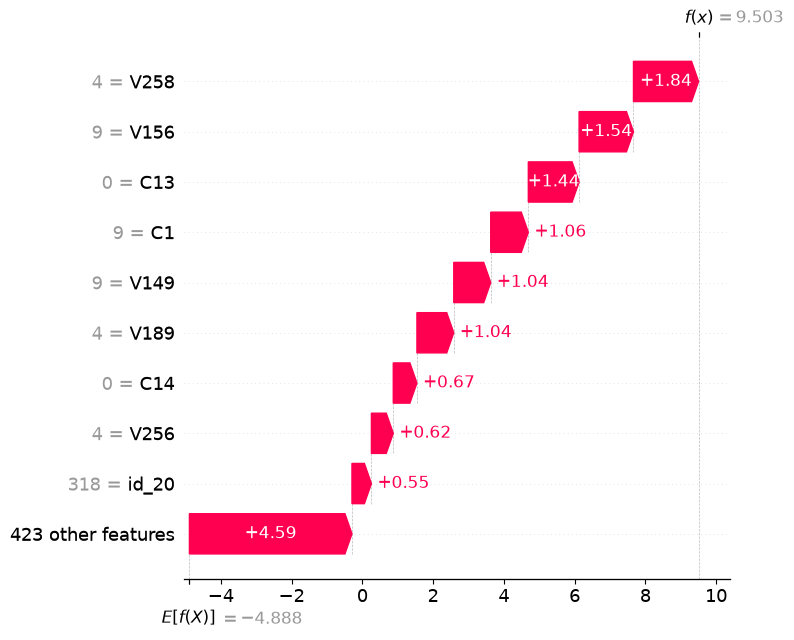

In [6]:
plot_transaction_explanation(explanation, index=idx_detected)

In [7]:
top_contributing_features(explanation, index=idx_detected, top_n=10)

,feature,valeur,impact_shap
309,V258,4.0,1.840423
207,V156,9.0,1.536861
26,C13,0.0,1.435215
14,C1,9.0,1.062532
200,V149,9.0,1.044955
240,V189,4.0,1.041067
27,C14,0.0,0.668458
307,V256,4.0,0.618096
410,id_20,318.0,0.549398
2,card1,4954.0,-0.482213


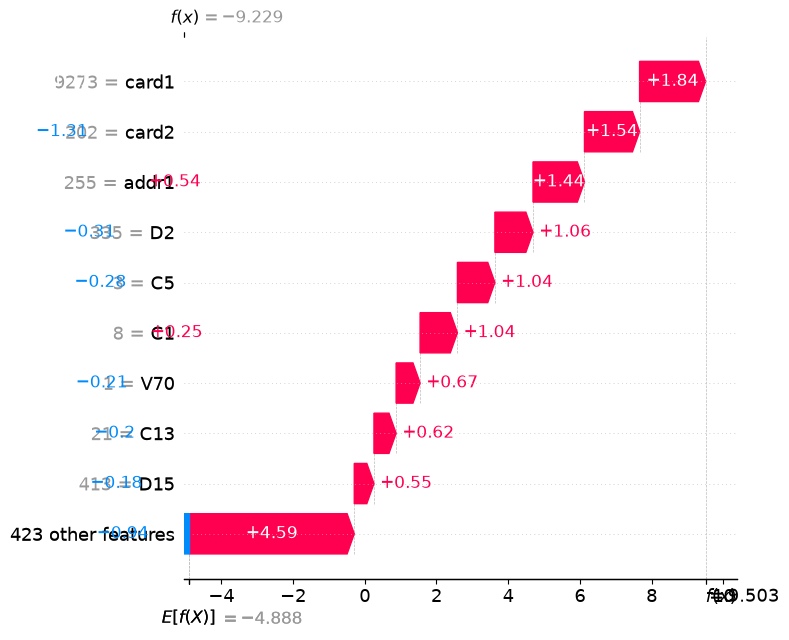

,feature,valeur,impact_shap
2,card1,9273.0,-1.705545
3,card2,202.0,-1.309086
8,addr1,255.0,0.541694
29,D2,335.0,-0.306699
18,C5,3.0,-0.284505
14,C1,8.0,0.247347
121,V70,1.0,-0.207909
26,C13,21.0,-0.200763
42,D15,413.0,-0.175801
142,V91,1.0,-0.154942


In [8]:
if idx_missed is not None:
    display(plot_transaction_explanation(explanation, index=idx_missed))
    display(top_contributing_features(explanation, index=idx_missed, top_n=10))